In [1]:
# WARNING #####################################################################
# this notebook should be run in Colab unless you have an already fully
# functional conda environment with both `tensorflow` and `cv2`.
# Remember to upload "emotion_model_weights.keras" file, the folders `shap`,
# and `test_img` in your google drive main directory.
###############################################################################
import os
import sys
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import kagglehub
import cv2
from google.colab.patches import cv2_imshow

In [2]:
# Mounting google drive into the current working session
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Kaggle and model configuration

In [3]:
# define the remote kaggle directory with the data
path = kagglehub.dataset_download("msambare/fer2013")
train_dir = os.path.join(path, 'train')
test_dir = os.path.join(path, 'test')
print(train_dir, test_dir)

Using Colab cache for faster access to the 'fer2013' dataset.
/kaggle/input/fer2013/train /kaggle/input/fer2013/test


In [4]:
# --- Configuration ---
MODEL_PATH = '/content/drive/MyDrive/emotion_model_weights.keras' # the trained model
IMG_SIZE = 48
BATCH_SIZE = 64


In [5]:

# --- 2. Load the Trained Model ---
if not os.path.exists(MODEL_PATH):
    print(f"\nError: Model file '{MODEL_PATH}' not found.")
    print("Please run the training script first to generate the weights.")
    sys.exit(1)


In [6]:

print(f"\nLoading model from {MODEL_PATH}...")
try:
    model = tf.keras.models.load_model(MODEL_PATH)
except Exception as e:
    print(f"Error loading model: {e}")
    sys.exit(1)



Loading model from /content/drive/MyDrive/emotion_model_weights.keras...


In [7]:

# --- 3. Load Validation Data ---
# IMPORTANT: shuffle=False
# We need the labels to stay in the exact same order as our predictions.
print(f"Loading validation data from: {test_dir}")
val_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    label_mode='categorical',
    shuffle=False
)


Loading validation data from: /kaggle/input/fer2013/test
Found 7178 files belonging to 7 classes.


In [8]:
val_ds.class_names

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

# Confusion Matrix

In [9]:

# --- 4. Generate Predictions ---
print("Generating predictions (this may take a moment)...")

# We extract the true labels (y_true) and predicted labels (y_pred)
y_true = []
y_pred = []

# Iterate over the dataset
for images, labels in val_ds:
    # Get predictions for this batch
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

print("DONE")

Generating predictions (this may take a moment)...
DONE


In [10]:

# --- 5. Define Class Names ---
class_names = val_ds.class_names
print(f"Classes found: {class_names}")


Classes found: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


Confusion matrix saved to 'confusion_matrix.png'


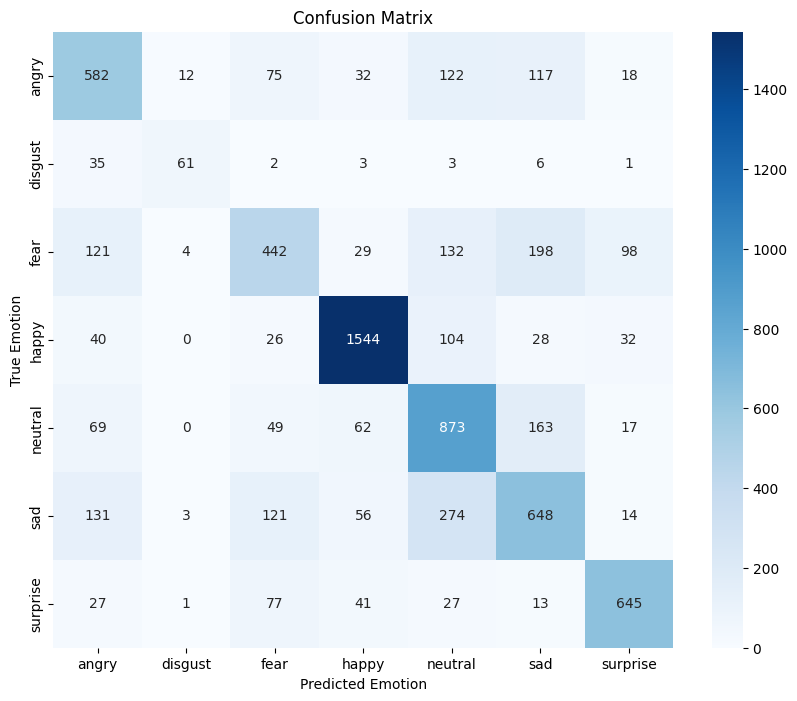

In [11]:

# --- 6. Plot Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Emotion')
plt.ylabel('True Emotion')

# Save the plot
plt.savefig('confusion_matrix.png')
print("Confusion matrix saved to 'confusion_matrix.png'")
plt.show()


In [12]:

# --- 7. Print Detailed Text Report ---
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))


Classification Report:
              precision    recall  f1-score   support

       angry       0.58      0.61      0.59       958
     disgust       0.75      0.55      0.64       111
        fear       0.56      0.43      0.49      1024
       happy       0.87      0.87      0.87      1774
     neutral       0.57      0.71      0.63      1233
         sad       0.55      0.52      0.54      1247
    surprise       0.78      0.78      0.78       831

    accuracy                           0.67      7178
   macro avg       0.67      0.64      0.65      7178
weighted avg       0.67      0.67      0.67      7178



# Precision and Recall

Confusion matrix saved to 'precision_and_recall.png'


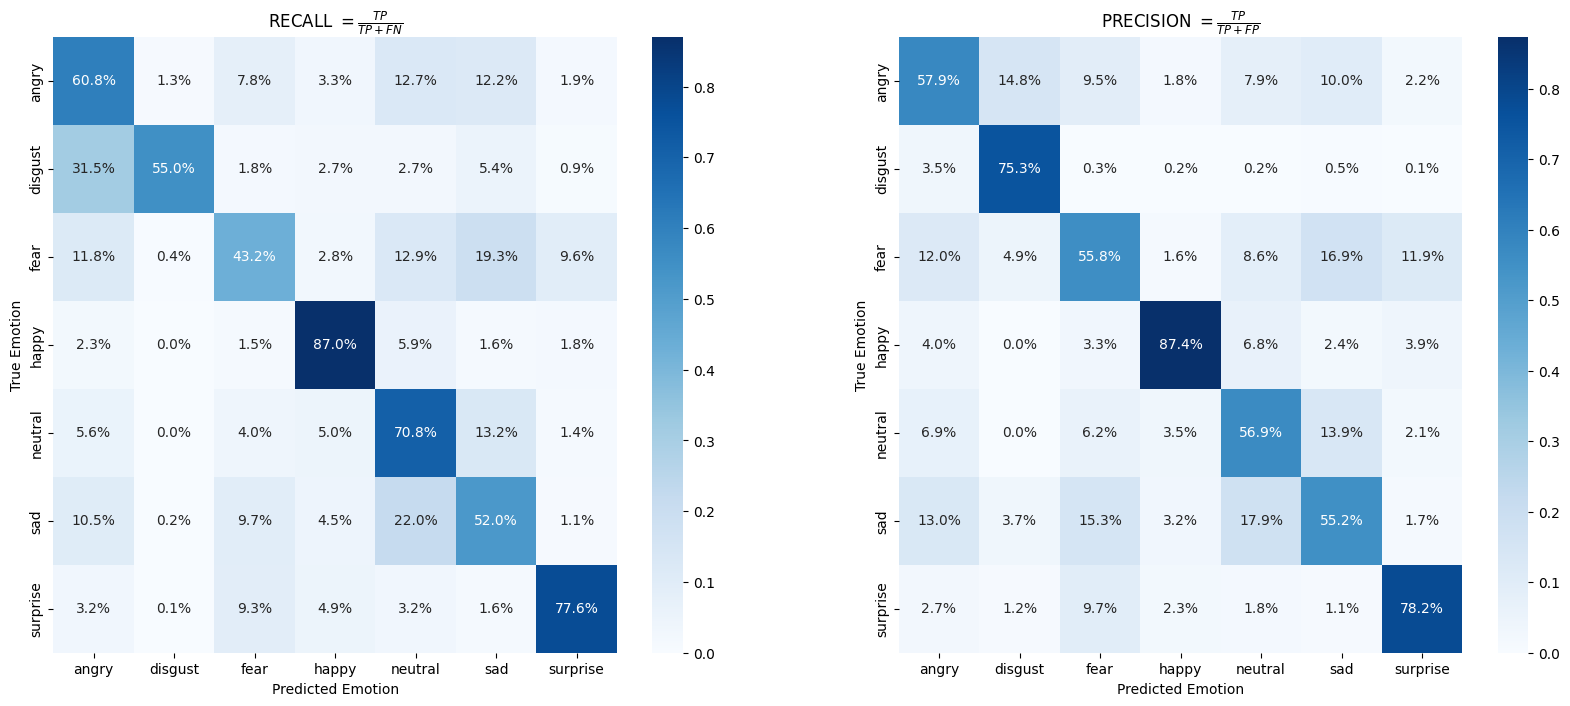

In [13]:

# --- 7. Plot Precision and Recall ---

fig, ax = plt.subplots(1, 2, figsize=(20, 8))
cmTrue = confusion_matrix(y_true, y_pred, normalize='true')
sns.heatmap(cmTrue, annot=True, fmt='.1%', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax[0])
ax[0].set_xlabel("Predicted Emotion")
ax[0].set_ylabel("True Emotion")
ax[0].set_title(r"RECALL $=\frac{ TP }{ TP + FN }$")
cmPred = confusion_matrix(y_true, y_pred, normalize='pred')
sns.heatmap(cmPred, annot=True, fmt='.1%', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax[1])
ax[1].set_xlabel("Predicted Emotion")
ax[1].set_ylabel("True Emotion")
ax[1].set_title(r"PRECISION $=\frac{ TP }{ TP + FP }$")
# Save the plot
plt.savefig('precision_and_recall.png')
print("Confusion matrix saved to 'precision_and_recall.png'")
plt.show()


# CV2 debug

In [14]:
def preview_image_processing(image_path):
    # 1. Load the image
    img = cv2.imread(image_path)

    if img is None:
        print(f"❌ ERROR: Could not load image from '{image_path}'")
        print("   - Check the filename spelling.")
        print("   - Make sure the file is in the SAME folder as this script.")
        return

    print(f"✅ Image loaded successfully. Shape: {img.shape}")

    # 2. Convert to Grayscale (Step 1 of preprocessing)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 3. Detect Face (Step 2 of preprocessing)
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

    if len(faces) == 0:
        print("⚠️ WARNING: No face detected! Showing the full image resize instead.")
        # Fallback: Resize the whole image if no face is found
        model_input = cv2.resize(gray, (48, 48))
        face_box = gray # For display purposes
    else:
        print(f"✅ Found {len(faces)} face(s). Showing the first one.")
        (x, y, w, h) = faces[0]

        # Draw a rectangle on the original for the preview
        cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)

        # Crop the face
        face_box = gray[y:y+h, x:x+w]

        # Resize to 48x48 (Step 3 of preprocessing)
        model_input = cv2.resize(face_box, (48, 48))

    # --- VISUALIZATION ---
    plt.figure(figsize=(12, 4))

    # Plot 1: Original Image (OpenCV reads in BGR, so we convert to RGB for Matplotlib display)
    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("1. Original (with Crop Box)")
    plt.axis('off')

    # Plot 2: The Cropped Face (Grayscale)
    plt.subplot(1, 3, 2)
    plt.imshow(face_box, cmap='gray')
    plt.title("2. Cropped Face (Gray)")
    plt.axis('off')

    # Plot 3: What the Model Actually Sees (48x48)
    plt.subplot(1, 3, 3)
    plt.imshow(model_input, cmap='gray')
    plt.title("3. Final Model Input (48x48)")
    plt.axis('off')

    plt.show()

/content/drive/MyDrive/test_img/anggg.jpg
✅ Image loaded successfully. Shape: (1071, 736, 3)
✅ Found 1 face(s). Showing the first one.


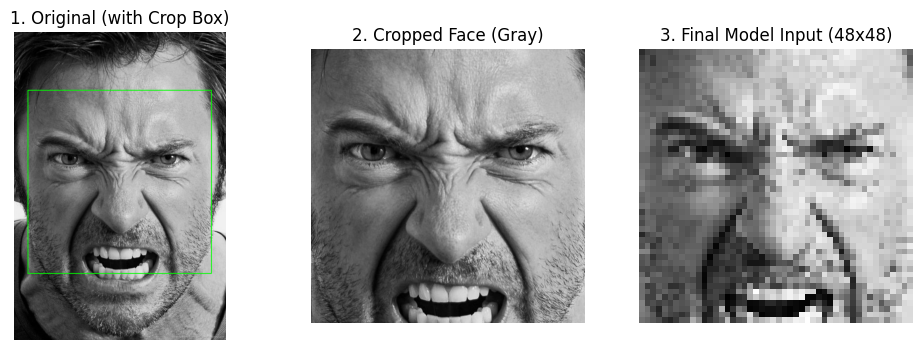

/content/drive/MyDrive/test_img/suprrr.jpg
✅ Image loaded successfully. Shape: (612, 596, 3)
✅ Found 1 face(s). Showing the first one.


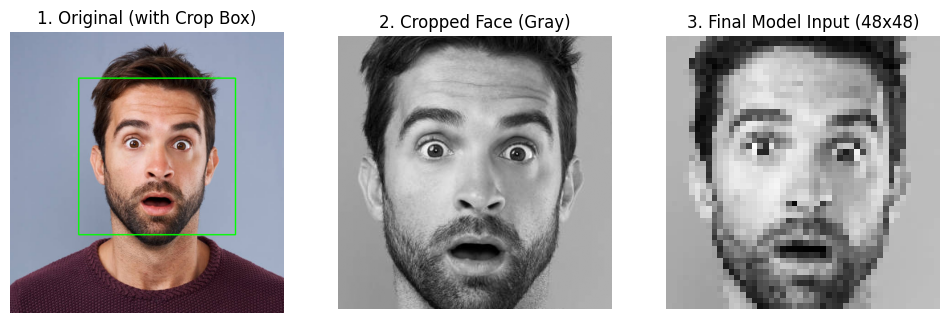

/content/drive/MyDrive/test_img/saddd.jpg
✅ Image loaded successfully. Shape: (691, 1000, 3)
✅ Found 1 face(s). Showing the first one.


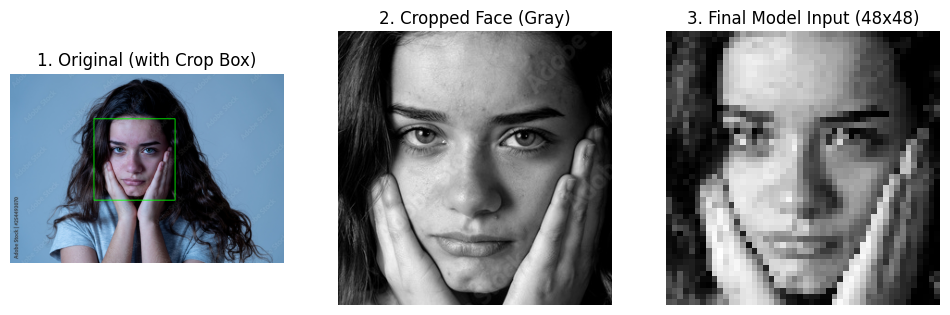

/content/drive/MyDrive/test_img/hapyyy.jpeg
✅ Image loaded successfully. Shape: (1600, 1066, 3)
✅ Found 2 face(s). Showing the first one.


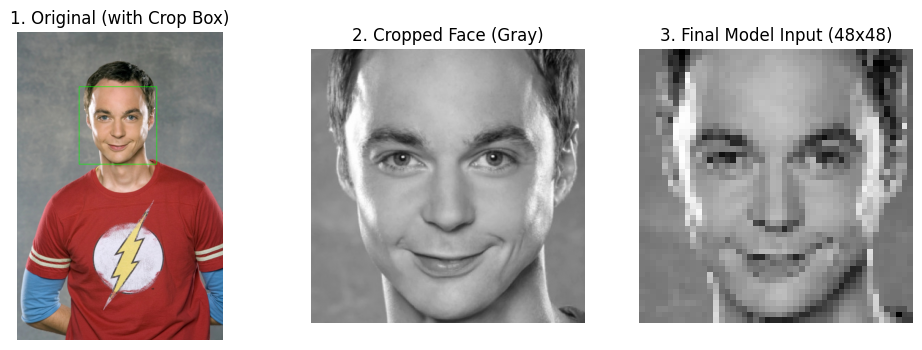

/content/drive/MyDrive/test_img/fearrr.jpg
✅ Image loaded successfully. Shape: (417, 626, 3)
✅ Found 1 face(s). Showing the first one.


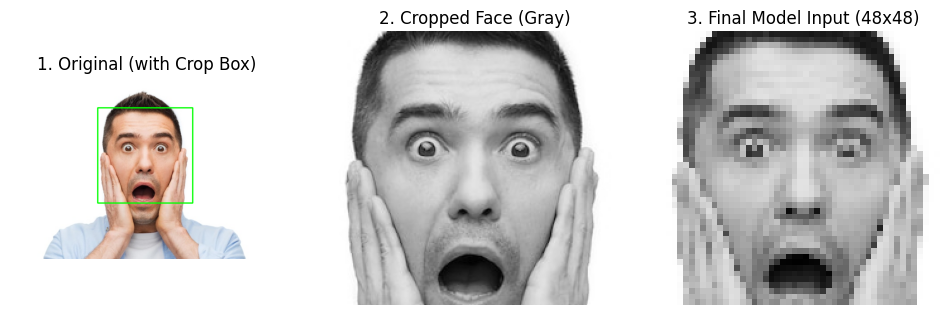

In [15]:
# Test images
IMG_DIR = "/content/drive/MyDrive/test_img/*"
from glob import glob
for img_path in glob(IMG_DIR, recursive=True):
    print(img_path)
    preview_image_processing(img_path)

# Test with images

In [16]:
def predict_emotion(image_path, model_path):
    # 1. Load the trained model
    try:
        model = tf.keras.models.load_model(model_path)
        print("Model loaded successfully.")
    except Exception as e:
        print(f"Error loading model: {e}")
        return

    # 2. Define class names (match the order of the training set)
    class_names = val_ds.class_names

    # 3. Read the image
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not load image at {image_path}. Check the path/filename.")
        return

    # --- Preprocessing ---
    # Convert to grayscale (Model expects 1 channel)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Resize to 48x48 (Model input size)
    resized = cv2.resize(gray, (48, 48))

    # Add batch dimension (1, 48, 48)
    input_data = np.expand_dims(resized, axis=0)

    # Add channel dimension (1, 48, 48, 1)
    input_data = np.expand_dims(input_data, axis=-1)

    # --- Prediction ---
    # The model handles the rescaling (1./255) internally, so we pass raw pixels
    prediction = model.predict(input_data)

    # Get the index of the highest probability
    result_index = np.argmax(prediction)
    confidence = np.max(prediction)
    predicted_emotion = class_names[result_index]

    print(f"\n--- Result ---")
    print(prediction)
    print(result_index)
    print(f"Emotion: {predicted_emotion}")
    print(f"Confidence: {confidence * 100:.2f}%")

    # Optional: Show the image with the label
    imS = cv2.resize(img, (200, 200))
    cv2.putText(imS, f"{predicted_emotion} ({confidence*100:.1f}%)", (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
    cv2_imshow(imS)
    cv2.waitKey(0) # Wait for a key press to close the window
    cv2.destroyAllWindows()



##########
/content/drive/MyDrive/test_img/anggg.jpg
Model loaded successfully.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step

--- Result ---
[[8.6933500e-01 1.5531964e-02 8.3082527e-02 1.5350668e-02 5.7008298e-04
  1.6033383e-02 9.6394688e-05]]
0
Emotion: angry
Confidence: 86.93%


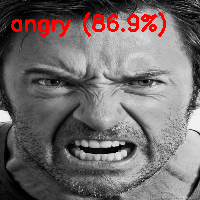



##########
/content/drive/MyDrive/test_img/suprrr.jpg
Model loaded successfully.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step

--- Result ---
[[0.05697111 0.00084266 0.1021589  0.2536553  0.17810076 0.14988281
  0.2583884 ]]
6
Emotion: surprise
Confidence: 25.84%


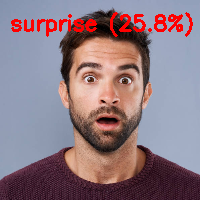



##########
/content/drive/MyDrive/test_img/saddd.jpg
Model loaded successfully.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step

--- Result ---
[[7.1149673e-03 8.0924219e-06 1.4239767e-01 3.4221447e-01 5.6989934e-02
  4.2391640e-01 2.7358446e-02]]
5
Emotion: sad
Confidence: 42.39%


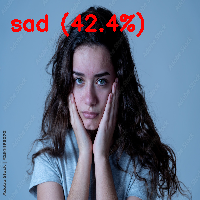



##########
/content/drive/MyDrive/test_img/hapyyy.jpeg
Model loaded successfully.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step

--- Result ---
[[3.7244868e-02 6.4256608e-05 9.4113657e-03 9.1244543e-01 2.2546399e-02
  7.1797217e-03 1.1107991e-02]]
3
Emotion: happy
Confidence: 91.24%


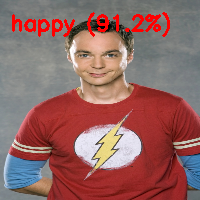



##########
/content/drive/MyDrive/test_img/fearrr.jpg
Model loaded successfully.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step

--- Result ---
[[0.14130074 0.00084781 0.39293995 0.06317167 0.08748576 0.05843831
  0.25581577]]
2
Emotion: fear
Confidence: 39.29%


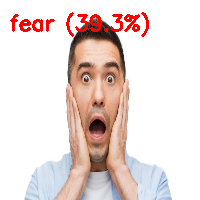

In [17]:
# --- Run the function ---
for img_path in glob(IMG_DIR, recursive=True):
    print(f"\n\n##########\n{img_path}")
    predict_emotion(image_path=img_path, model_path=MODEL_PATH)